#TASK 1 – Breadth-First Search (BFS)
Problem: Emergency Exit Finder

A building floor is represented as a grid:

building = [

[1, 1, 0, 1],

[0, 1, 1, 1],

[1, 1, 0, 1],

[1, 0, 1, 1]

]

Where 1 = Walkable path, 0 = Blocked path

Start position: (0,0)

Emergency Exit: (3,3)

Movement allowed: Up, Down, Left, Right

Requirements:
1. Convert grid into graph (adjacency list).
2. Implement Breadth-First Search.
3. Print traversal order and shortest path.

In [10]:
building = [
    [1, 1, 0, 1],
    [0, 1, 1, 1],
    [1, 1, 0, 1],
    [1, 0, 1, 1]
]

def makeGraph(maze):
    adj = {}
    h = len(maze)
    w = len(maze[0])
    for r in range(h):
        for c in range(w):
            if maze[r][c] == 1:
                moves = []
                for dr, dc in [(-1,0), (1,0), (0,-1), (0,1)]:
                    nr, nc = r + dr, c + dc
                    if 0 <= nr < h and 0 <= nc < w and maze[nr][nc] == 1:
                        moves.append((nr, nc))
                adj[(r, c)] = moves
    return adj

def bfs(graph, start, end):
    q = [start]
    seen = [start]
    parentMap = {start: None}

    while q:
        curr = q.pop(0)
        print("at node:", curr)

        if curr == end:
            print("found exit")
            break

        for nxt in graph.get(curr, []):
            if nxt not in seen:
                seen.append(nxt)
                parentMap[nxt] = curr
                q.append(nxt)
    path = []
    step = end
    while step is not None:
        path.append(step)
        step = parentMap[step]
    path.reverse()
    return path

gridGraph = makeGraph(building)
path = bfs(gridGraph, (0,0), (3,3))
print("final route:", path)

at node: (0, 0)
at node: (0, 1)
at node: (1, 1)
at node: (2, 1)
at node: (1, 2)
at node: (2, 0)
at node: (1, 3)
at node: (3, 0)
at node: (0, 3)
at node: (2, 3)
at node: (3, 3)
found exit
final route: [(0, 0), (0, 1), (1, 1), (1, 2), (1, 3), (2, 3), (3, 3)]


#TASK 2 – Depth-Limited Search (DLS)
Problem: Limited Energy Drone

Graph representation:graph = {

'A': ['B', 'C'],

'B': ['D', 'E'],

'C': ['F'],

'D': ['G'],

'E': [],

'F': ['H'],

'G': [],

'H': []

}

Start node: 'A'

Goal node: 'H'

Depth limit: 3

Requirements:
1. Implement Depth-Limited Search using recursion.
2. Add depth limit as parameter.
3. Show nodes visited and path if goal found.
4. Run with depth = 2 and depth = 3.

In [11]:
droneMap = {
    'A': ['B', 'C'],
    'B': ['D', 'E'],
    'C': ['F'],
    'D': ['G'],
    'E': [],
    'F': ['H'],
    'G': [],
    'H': []
}

def dls(curr, target, limit, currentPath):
    print("checking node:", curr)
    if curr == target:
        return currentPath + [curr]

    if limit <= 0:
        return None

    for nxt in droneMap.get(curr, []):
        result = dls(nxt, target, limit - 1, currentPath + [curr])
        if result:
            return result
    return None

start = 'A'
goal = 'H'
print("for depth 2: ")
path2 = dls(start, goal, 2, [])
if path2:
    print("path found:", path2)
else:
    print("goal not found ")

print("for depth 3: ")
path3 = dls(start, goal, 3, [])
if path3:
    print("path found:", path3)
else:
    print("goal not found ")

for depth 2: 
checking node: A
checking node: B
checking node: D
checking node: E
checking node: C
checking node: F
goal not found 
for depth 3: 
checking node: A
checking node: B
checking node: D
checking node: G
checking node: E
checking node: C
checking node: F
checking node: H
path found: ['A', 'C', 'F', 'H']


#TASK 3 – Iterative Deepening Search (IDS)
Problem: Treasure Hunt

Use the same graph as Task 2.

Start node: 'A'

Goal node: 'G'

Requirements:
1. Implement Iterative Deepening Search.
2. Show each depth level clearly.
3. Print final path when goal is found.

In [12]:
huntMap = {
    'A': ['B', 'C'],
    'B': ['D', 'E'],
    'C': ['F'],
    'D': ['G'],
    'E': [],
    'F': ['H'],
    'G': [],
    'H': []
}

def dlsHelper(node, goal, depth, path):
    if node == goal:
        return path + [node]

    if depth <= 0:
        return None
    for neighbor in huntMap.get(node, []):
        res = dlsHelper(neighbor, goal, depth - 1, path + [node])
        if res:
            return res
    return None

def runIds(startNode, targetNode, maxD):
    for currentLimit in range(maxD + 1):
        print("depth limit:", currentLimit)

        finalPath = dlsHelper(startNode, targetNode, currentLimit, [])

        if finalPath:
            print("treasure found at level", currentLimit)
            print("final path:", " -> ".join(finalPath))
            return
        else:
            print("not found at this depth.")

start = 'A'
treasure = 'G'
runIds(start, treasure, 4)

depth limit: 0
not found at this depth.
depth limit: 1
not found at this depth.
depth limit: 2
not found at this depth.
depth limit: 3
treasure found at level 3
final path: A -> B -> D -> G


#TASK 4 – Uniform Cost Search (UCS)
Problem: Delivery Route Optimization

Weighted graph:

graph = {

'S': {'A': 4, 'B': 2},

'A': {'C': 5, 'D': 10},

'B': {'E': 3},

'C': {'G': 4},

'D': {'G': 1},

'E': {'D': 4},

'G': {}

}

Start node: 'S'

Goal node: 'G'

Requirements:
1. Implement Uniform Cost Search.
2. Maintain frontier (priority-based), cost tracking, and path reconstruction.
3. Print least cost path and total cost.

In [15]:
deliveryMap = {
    'S': {'A': 4, 'B': 2},
    'A': {'C': 5, 'D': 10},
    'B': {'E': 3},
    'C': {'G': 4},
    'D': {'G': 1},
    'E': {'D': 4},
    'G': {}
}

def ucs(graph, start, goal):
    frontier = [(start, 0, [start])]
    visitedNodes = []
    while frontier:
        frontier.sort(key=lambda x: x[1])
        currNode, currCost, currPath = frontier.pop(0)
        if currNode in visitedNodes:
            continue

        visitedNodes.append(currNode)
        if currNode == goal:
            print("goal reached ")
            print("route:", currPath)
            print("total cost:", currCost)
            return

        for neighbor, edgeWeight in graph.get(currNode, {}).items():
            if neighbor not in visitedNodes:
                newTotal = currCost + edgeWeight
                frontier.append((neighbor, newTotal, currPath + [neighbor]))
    print("no route found")

ucs(deliveryMap, 'S', 'G')

goal reached 
route: ['S', 'B', 'E', 'D', 'G']
total cost: 10


# TASK 5 - Best First Search
Enhanced Maze Navigation with Multiple Goals

● Description: Modify the given Best-First Search to find a path through a maze
with multiple goal points. The algorithm should visit all goal points and return
the shortest path covering all goals.

● Challenge: The maze will have several dead ends and multiple goal points at
different locations.
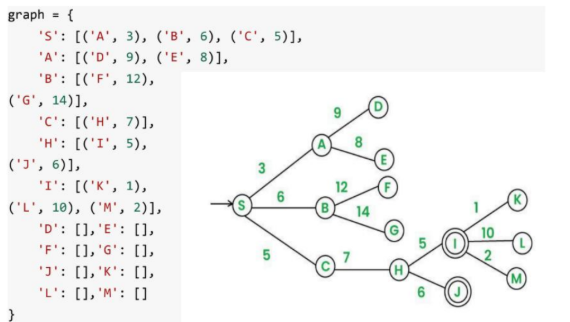

In [16]:
mazeGraph = {
    'S': [('A', 3), ('B', 6), ('C', 5)],
    'A': [('D', 9), ('E', 8)],
    'B': [('F', 12), ('G', 14)],
    'C': [('H', 7)],
    'H': [('I', 5), ('J', 6)],
    'I': [('K', 1), ('L', 10), ('M', 2)],
    'D': [], 'E': [], 'F': [], 'G': [], 'J': [], 'L': [], 'M': [], 'K': []
}

def multiGoalSearch(graph, start, targetGoals):
    openList = [(0, start, [start])]
    visited = []
    foundList = []

    while openList:
        openList.sort()
        hValue, node, path = openList.pop(0)

        if node not in visited:
            visited.append(node)

            if node in targetGoals and node not in foundList:
                foundList.append(node)
                if len(foundList) == len(targetGoals):
                    return path

            for neighbor, weight in graph.get(node, []):
                if neighbor not in visited:
                    openList.append((weight, neighbor, path + [neighbor]))
    return None

goalsToFind = ['I', 'J']
finalPath = multiGoalSearch(mazeGraph, 'S', goalsToFind)
print("path found for all goals:", finalPath)

path found for all goals: ['S', 'C', 'H', 'J']


#TASK 6 - A*
Implement an A* Search where the edge costs change dynamically at random intervals. The algorithm should adapt to these changes and always find the optimal path.

Recompute and adjust paths in real time without restarting the algorithm from scratch.Randomly increase or decrease one edge cost.

Example:

• A–B changes from 4 → 8

• B–E changes from 12 → 7

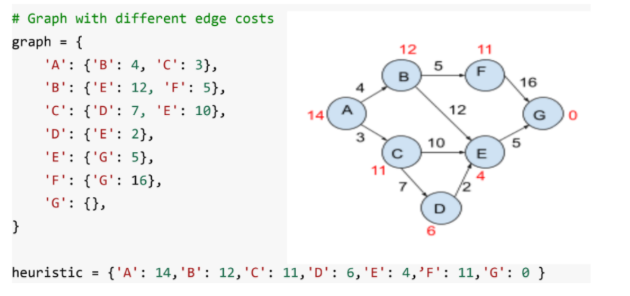

In [17]:
graph1 = {
    'A': {'B': 4, 'C': 3},
    'B': {'E': 12, 'F': 5},
    'C': {'D': 7, 'E': 10},
    'D': {'E': 2},
    'E': {'G': 5},
    'F': {'G': 16},
    'G': {}
}

heuristic = {'A': 14, 'B': 12, 'C': 11, 'D': 6, 'E': 4, 'F': 11, 'G': 0}

def aStarLogic(graph, start, goal, hMap):
    searchQueue = [(0 + hMap[start], 0, start, [start])]
    seen = {}

    while searchQueue:
        searchQueue.sort()
        f, g, current, route = searchQueue.pop(0)
        if current == goal:
            return route, g

        if current in seen and seen[current] <= g:
            continue
        seen[current] = g

        for nxt, weight in graph.get(current, {}).items():
            newG = g + weight
            newF = newG + hMap[nxt]
            searchQueue.append((newF, newG, nxt, route + [nxt]))
    return None, 0

resPath, resCost = aStarLogic(graph1, 'A', 'G', heuristic)
print("org path:", resPath, "cost:", resCost)

print("B->E cost changes from 12 to 7")
graph1['B']['E'] = 7

newResPath, newResCost = aStarLogic(graph1, 'A', 'G', heuristic)
print("new optimal path:", newResPath, "new cost:", newResCost)

org path: ['A', 'C', 'D', 'E', 'G'] cost: 17
B->E cost changes from 12 to 7
new optimal path: ['A', 'B', 'E', 'G'] new cost: 16
